# Моделирование аффективных характеристик лексики на основе ассоциативно-вербальной сети

In [2]:
!pip install pandas matplotlib seaborn scipy statsmodels openpyxl -q
!pip install adjustText -q


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.linear_model import RidgeCV
from scipy.special import logit, expit
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text


## Этап I. Анализ данных

**Основная задача данного проекта** – расширить разметку по аффективным параметрам для словника создаваемого ассоциативного словаря.

**Материал**. База данных ассоциативного словаря русского языка объемом 156 тысяч пар стимул-ассоциация. 37 тысяч пар имеют разметку по трем аффективным параметрам valence, arousal, dominance. Эта разметка осуществлялась на основе базы данных аффективных норм (на базе массовых опросов среди носителей русского языка).

**Гипотеза**. На основе известных аффективных профилей ассоциаций и стимулов возможно предсказать аффективные профили других пар. Структура ассоциативно-вербальной сети (ментального лексикона) является более точным предиктором аффективных параметров значения слова (*valence, arousal, dominance*), чем дистрибутивно-семантические модели, обученные на больших текстовых корпусах. Стимулы и ассоциации обладают связью иного порядка, чем слова, которые часто встречаются вместе в одном контексте.


In [4]:
df_all = pd.read_excel('1. Общий словарь_ML.xlsx')
df_vad = pd.read_excel('1. VAD_ML.xlsx')

In [5]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146214 entries, 0 to 146213
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   стимул   146214 non-null  object
 1   лемма    146214 non-null  object
 2   частота  146214 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.3+ MB


In [6]:
df_vad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37005 entries, 0 to 37004
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   стимул                 37005 non-null  object 
 1   лемма                  37005 non-null  object 
 2   частота                37005 non-null  int64  
 3   часть речи стимула     37005 non-null  object 
 4   часть речи ассоциации  37005 non-null  object 
 5   st_arousal             37005 non-null  float64
 6   st_dominance           37005 non-null  float64
 7   st_valence             37005 non-null  float64
 8   st_abstract            37005 non-null  float64
 9   ass_arousal            37005 non-null  float64
 10  ass_dominance          37005 non-null  float64
 11  ass_valence            37005 non-null  float64
 12  ass_abstract           37005 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 3.7+ MB


### 1.1. Описательная статистика

In [7]:
display(df_vad[['st_valence', 'st_arousal', 'st_dominance']].describe().round(2))

,st_valence,st_arousal,st_dominance
count,37005.00,37005.00,37005.00
mean,3.65,3.28,3.26
std,0.64,0.53,0.55
min,1.09,1.25,1.31
25%,3.31,2.97,2.97
50%,3.70,3.21,3.21
75%,4.07,3.70,3.68
max,4.96,4.70,4.83


In [8]:
display(df_vad[['ass_valence', 'ass_arousal', 'ass_dominance']].describe().round(2))

,ass_valence,ass_arousal,ass_dominance
count,37005.00,37005.00,37005.00
mean,3.82,3.31,3.34
std,0.66,0.58,0.56
min,1.09,1.25,1.31
25%,3.50,2.97,3.03
50%,3.87,3.25,3.30
75%,4.30,3.77,3.77
max,4.96,4.70,4.83


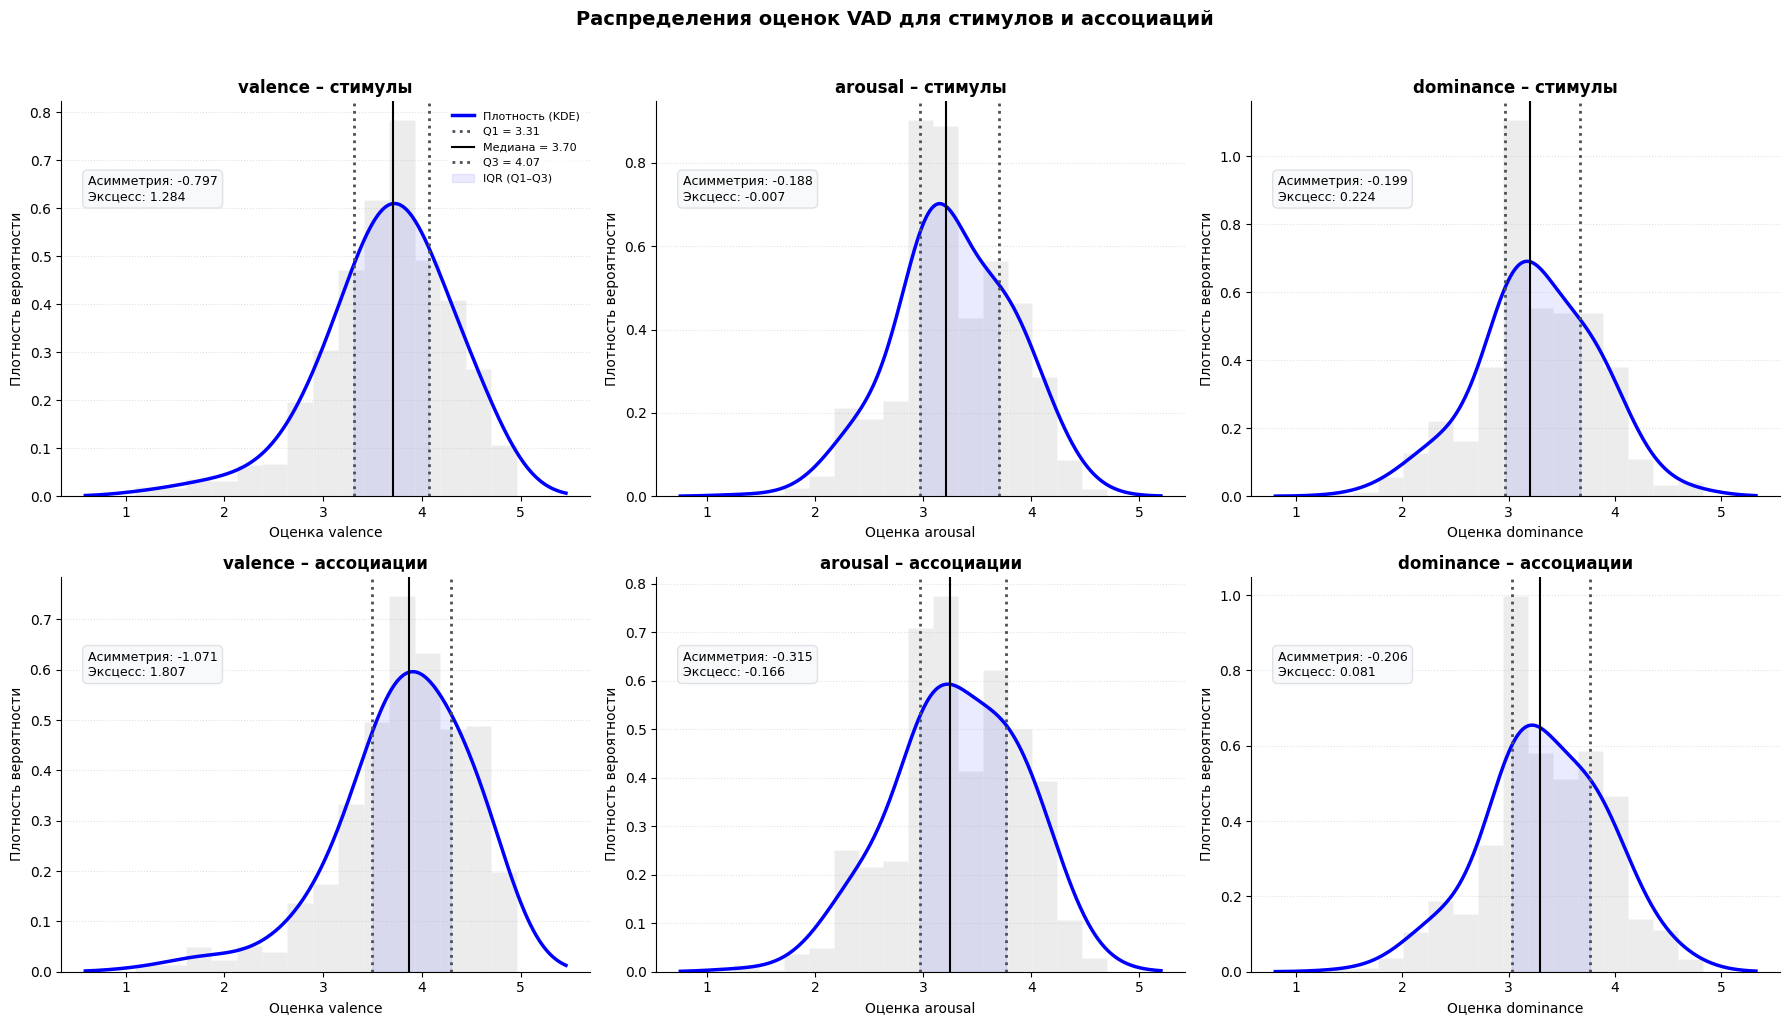

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
fig.suptitle('Распределения оценок VAD для стимулов и ассоциаций',
             fontsize=14, fontweight='bold', y=1.02)

cols_st = ['st_valence', 'st_arousal', 'st_dominance']
cols_ass = ['ass_valence', 'ass_arousal', 'ass_dominance']
scales = ['valence', 'arousal', 'dominance']

for row_idx, (col_list, row_label) in enumerate(zip([cols_st, cols_ass], ['стимулы', 'ассоциации'])):
    for col_idx, (col, scale) in enumerate(zip(col_list, scales)):
        ax = axes[row_idx, col_idx]
        data = df_vad[col].dropna()

        # KDE и гистограмма
        kde = stats.gaussian_kde(data, bw_method=0.5)
        x_range = np.linspace(data.min() - 0.5, data.max() + 0.5, 500)
        y_kde = kde(x_range)
        ax.hist(data, bins=15, density=True, alpha=0.15, color='gray', edgecolor='white')
        ax.plot(x_range, y_kde, color='blue', linewidth=2.5, label='Плотность (KDE)')

        # квартили
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        median = data.median()
        ax.axvline(q1, color='#495057', linestyle=':', linewidth=2, label=f'Q1 = {q1:.2f}')
        ax.axvline(median, color='black', linestyle='-', linewidth=1.5, label=f'Медиана = {median:.2f}')
        ax.axvline(q3, color='#495057', linestyle=':', linewidth=2, label=f'Q3 = {q3:.2f}')

        # межквартильный размах
        x_iqr = np.linspace(q1, q3, 100)
        ax.fill_between(x_iqr, 0, kde(x_iqr), color='blue', alpha=0.08, label='IQR (Q1–Q3)')

        # форма распределения
        ax.text(0.05, 0.75, f"Асимметрия: {data.skew():.3f}\nЭксцесс: {data.kurt():.3f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4", facecolor='#f8f9fa', edgecolor='#dee2e6'))

        ax.set_title(f"{scale} – {row_label}", fontsize=12, fontweight='bold')
        ax.set_xlabel(f"Оценка {scale}", fontsize=10)
        ax.set_ylabel("Плотность вероятности", fontsize=10)
        ax.grid(axis='y', linestyle=':', alpha=0.4, color='#adb5bd')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=8)

plt.tight_layout()
plt.show()

Таким образом, описательные статистики рисуют следующую картину. Аффективные оценки стимулов и ассоциаций в целом близки, имеют схожую форму распределений, но ассоциативные реакции систематически сдвинуты в сторону чуть большей позитивности – valence и доминантности – dominance, при практически идентичном уровне возбуждения – arousal.

### 1.2. Статистика вывода

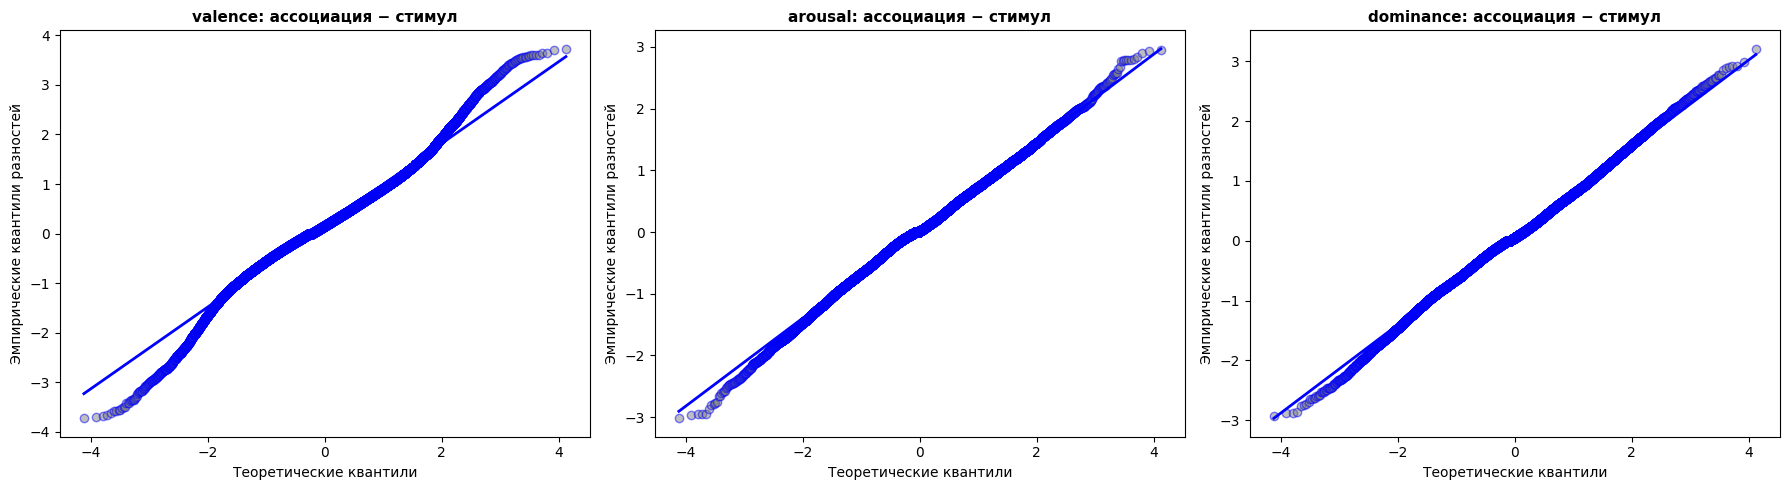

In [10]:
pairs = [('st_valence', 'ass_valence', 'valence'),
         ('st_arousal', 'ass_arousal', 'arousal'),
         ('st_dominance', 'ass_dominance', 'dominance')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (st_col, ass_col, name) in enumerate(pairs):
    diff = df_vad[ass_col] - df_vad[st_col]
    diff = diff.dropna()
    ax = axes[idx]
    stats.probplot(diff, dist="norm", plot=ax)

    ax.get_lines()[0].set_markerfacecolor('gray')
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('blue')
    ax.get_lines()[1].set_linewidth(2)

    ax.set_title(f'{name}: ассоциация − стимул', fontsize=11, fontweight='bold')
    ax.set_xlabel('Теоретические квантили')
    ax.set_ylabel('Эмпирические квантили разностей')

plt.tight_layout()
plt.show()

In [11]:
for st_col, ass_col, name in pairs:
    v1 = df_vad[st_col].dropna()
    v2 = df_vad[ass_col].dropna()
    # общий индекс для парного сравнения
    common_idx = v1.index.intersection(v2.index)
    v1 = v1.loc[common_idx]
    v2 = v2.loc[common_idx]
    diff = v2 - v1

    print(f"\n{name}")
    print(f"Среднее {st_col}: {v1.mean():.4f}")
    print(f"Среднее {ass_col}: {v2.mean():.4f}")

    # парный t-критерий
    t_stat, p_t = stats.ttest_rel(v2, v1)
    d_cohen = diff.mean() / diff.std(ddof=1)
    print(f"Парный t-критерий: t = {t_stat:.4f}, p = {p_t:.5f}, d Коэна = {d_cohen:.4f}")

    # тест Уилкоксона
    w_obs, p_w = stats.wilcoxon(v2, v1)
    n_w = (diff != 0).sum()
    w_expected = n_w * (n_w + 1) / 4
    r_bi = 1 - (2 * w_obs) / (n_w * (n_w + 1) / 2) if n_w > 0 else 0
    print(f"Уилкоксон: W = {w_obs:.1f} (ожидаемое {w_expected:.1f}), p = {p_w:.5f}, r_biserial = {r_bi:.4f}")

    # интерпретация
    if p_w < 0.05:
        median_diff = diff.median()
        direction = "увеличения" if median_diff > 0 else "уменьшения"
        print(f"Результат: значимый сдвиг в сторону {direction} ассоциаций (медиана разности = {median_diff:.3f}).")
    else:
        print("Результат: статистически значимых различий не обнаружено.")


valence
Среднее st_valence: 3.6475
Среднее ass_valence: 3.8180
Парный t-критерий: t = 39.4508, p = 0.00000, d Коэна = 0.2051
Уилкоксон: W = 245898452.5 (ожидаемое 331868197.5), p = 0.00000, r_biserial = 0.2590
Результат: значимый сдвиг в сторону увеличения ассоциаций (медиана разности = 0.159).

arousal
Среднее st_arousal: 3.2803
Среднее ass_arousal: 3.3129
Парный t-критерий: t = 8.7899, p = 0.00000, d Коэна = 0.0457
Уилкоксон: W = 308005682.5 (ожидаемое 328379701.5), p = 0.00000, r_biserial = 0.0620
Результат: значимый сдвиг в сторону увеличения ассоциаций (медиана разности = 0.017).

dominance
Среднее st_dominance: 3.2646
Среднее ass_dominance: 3.3381
Парный t-критерий: t = 19.1686, p = 0.00000, d Коэна = 0.0996
Уилкоксон: W = 290914762.0 (ожидаемое 328996113.0), p = 0.00000, r_biserial = 0.1158
Результат: значимый сдвиг в сторону увеличения ассоциаций (медиана разности = 0.058).


Парные сравнения подтвердили статистически значимое, хотя и небольшое, превышение оценок ассоциаций над стимулами по всем трём шкалам. Для эмоциональной окраски (valence) разница средних составила +0,17 (t = 39,45, p < 0,001; d Коэна = 0,21; рангово-бисериальный r = 0,26), что соответствует малому-умеренному эффекту. Для dominance сдвиг меньше (+0,07; t = 19,17, p < 0,001; d = 0,10; r = 0,12) – эффект малый. Для arousal разница минимальна (+0,03; t = 8,79, p < 0,001; d = 0,05; r = 0,06) – эффект пренебрежимо мал и достигает значимости лишь благодаря большому объёму выборки. Таким образом, ассоциативный процесс сопровождается избирательным повышением позитивности реакций при очень слабом росте доминантности и практически неизменном уровне возбуждения.

### 1.4. Регрессия

In [12]:
stimulus_col = 'стимул'
stim_means = df_vad.groupby(stimulus_col).agg(
    st_valence       = ('st_valence', 'first'),
    st_arousal       = ('st_arousal', 'first'),
    st_dominance     = ('st_dominance', 'first'),
    ass_valence_mean = ('ass_valence', 'mean'),
    ass_arousal_mean = ('ass_arousal', 'mean'),
    ass_dominance_mean= ('ass_dominance', 'mean'),
    count            = ('ass_valence', 'count')
).reset_index()


stim_means.rename(columns={stimulus_col: 'stimulus'}, inplace=True)

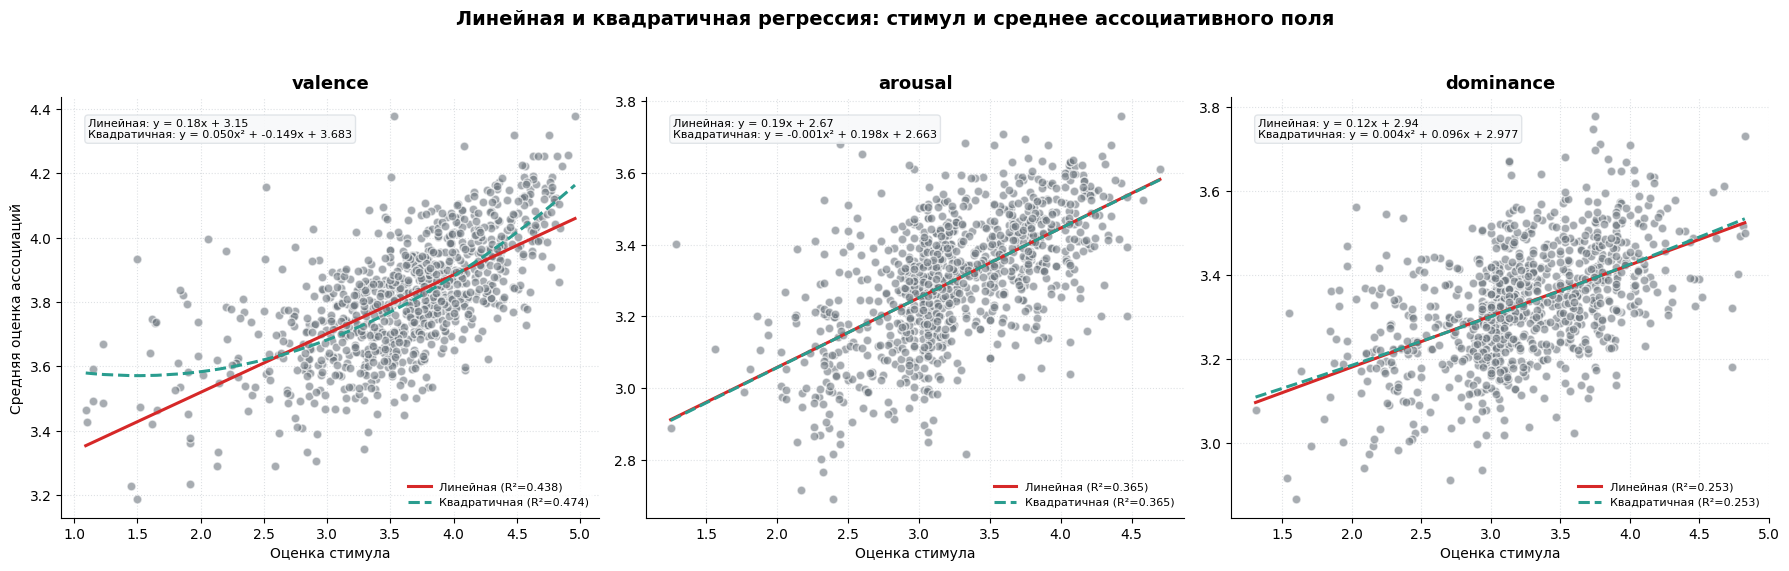

In [13]:

pairs_stim = [
    ('st_valence', 'ass_valence_mean', 'valence'),
    ('st_arousal', 'ass_arousal_mean', 'arousal'),
    ('st_dominance', 'ass_dominance_mean', 'dominance')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')
fig.suptitle('Линейная и квадратичная регрессия: стимул и среднее ассоциативного поля',
             fontsize=14, fontweight='bold', y=1.03)

for idx, (st_col, ass_col, name) in enumerate(pairs_stim):
    ax = axes[idx]
    subset = stim_means[[st_col, ass_col]].dropna()
    x = subset[st_col].values
    y = subset[ass_col].values

    # линейная регрессия
    lin = stats.linregress(x, y)
    r2_lin = lin.rvalue ** 2
    y_pred_lin = lin.intercept + lin.slope * x

    # квадратичная регрессия
    coeffs = np.polyfit(x, y, 2)
    y_pred_quad = np.polyval(coeffs, x)
    ss_res = np.sum((y - y_pred_quad) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_quad = 1 - ss_res / ss_tot

    # диаграмма рассеяния
    ax.scatter(x, y, alpha=0.6, edgecolors='white', s=40, color='#6c757d')

    # линии регрессии
    x_sorted = np.sort(x)
    ax.plot(x_sorted, lin.intercept + lin.slope * x_sorted,
            color='#d62828', linewidth=2.2, label=f'Линейная (R²={r2_lin:.3f})')
    ax.plot(x_sorted, np.polyval(coeffs, x_sorted),
            color='#2a9d8f', linewidth=2.2, linestyle='--', label=f'Квадратичная (R²={r2_quad:.3f})')


    textstr = f'Линейная: y = {lin.slope:.2f}x + {lin.intercept:.2f}\nКвадратичная: y = {coeffs[0]:.3f}x² + {coeffs[1]:.3f}x + {coeffs[2]:.3f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', edgecolor='#dee2e6', alpha=0.9))


    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Оценка стимула', fontsize=10)
    if idx == 0:
        ax.set_ylabel('Средняя оценка ассоциаций', fontsize=10)
    ax.grid(axis='both', linestyle=':', alpha=0.4, color='#adb5bd')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=8)

plt.tight_layout()
plt.show()

Сравнение линейной и квадратичной регрессий подтверждает, что связь между оценкой стимула и средними характеристиками его ассоциативного поля преимущественно линейна, однако сила этой связи различается по шкалам. Для эмоциональной окраски (valence) линейная модель объясняет 43,8% дисперсии, а квадратичная — 47,5%, что указывает на небольшую, но заметную U‑образную составляющую (коэффициент при x² положителен).  Для возбуждения (arousal) и доминантности (dominance) квадратичный член не даёт практически никакого прироста (R² остаётся 0,365 и 0,253 соответственно), что говорит о линейном характере зависимости. Таким образом, наиболее тесная линейная связь наблюдается для valence (R² ≈ 0,44), тогда как для arousal и dominance она слабее и не содержит заметной криволинейности. Эти результаты могут указывать на то, что valence будет предсказываться точнее.

Поскольку усреднённые аффективные характеристики ассоциативного поля статистически значимо связаны с оценками самого стимула и подчиняются преимущественно линейной зависимости, дистрибутивно-семантические признаки слова должны позволять предсказывать средние VAD-оценки его ассоциаций. **Ожидается, что:**
 - valence будет предсказываться точнее, чем arousal и dominance. Это следует из наибольшей величины эффекта сдвига «стимул → ассоциация» (d ≈ 0.21) и самой высокой доли объясняемой дисперсии в регрессионной модели (R² ≈ 0.44).

 - Линейные модели окажутся достаточными для всех трёх шкал. Регрессионный анализ не выявил существенной криволинейности (для arousal и dominance квадратичность не даёт прироста R²; для valence — лишь незначительный), поэтому добавление нелинейных методов не должно приводить к заметному улучшению.




Проверка этой гипотезы позволит установить, в какой мере аффективный профиль ассоциативного поля слова закодирован в его дистрибутивном поведении


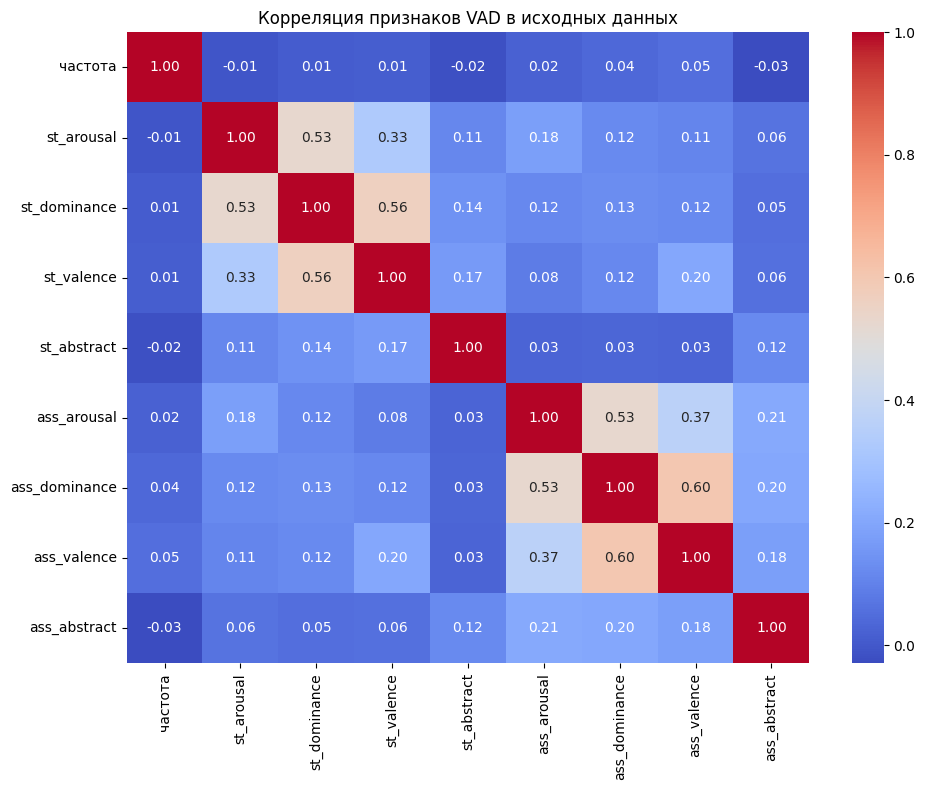

In [14]:
plt.figure(figsize=(10, 8))
# !метод Спирмена для устойчивости к нелинейности и выбросам (частоте, закон Ципфа)
sns.heatmap(df_vad.select_dtypes(include=['number']).corr(method='spearman'),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков VAD в исходных данных")
plt.tight_layout()
plt.show()

## Этап II. Подготовка данных

На данном этапе подготавливаются данные для обучения всего корпуса ассоциаций. Методология опирается на подход, предложенный в статье (Vankrunkelsven, 2018).

**Основные этапы:**
1. Предварительная фильтрация. Из анализа были исключены многословные ассоциации (т.е. словосочетания), а также шумовые реакции с абсолютной частотой во всем корпусе менее 2.
2. Взвешивание частоты ассоциативных связей (положительная точечная взаимная информация, PPMI). Простые частоты совместной встречаемости (стимул-реакция) смещены в сторону высокочастотных слов языка (актуализируется закон Ципфа). Для устранения этого искажения матрица частот преобразуется с помощью метрики Positive Pointwise Mutual Information (PPMI). Этот шаг позволяет штрафовать тривиальные, общеупотребительные ассоциации и присваивать высокий вес специфичным исемантически значимым связям.  
3. Вычисление косинусного сходства. На основе полученной матрицы весов PPMI вычисляется косинусное сходство между всеми парами слов. Два слова считаются семантически близкими, если они обладают схожим профилем распределения ассоциативных связей.  
4. Целевые переменные. На финальном этапе из полученной матрицы извлекались только те целевые слова, для которых существуют агрегированные оценки по шкалам valence, arousal, dominance.


In [15]:
# исключение многословных ассоциаций (словосочетаний)
df_all = df_all[~df_all['лемма'].str.contains(r'\s', na=False)]


unique_stimuli = set(df_all['стимул'])
unique_associations = set(df_all['лемма'])
overlap_words = unique_associations.intersection(unique_stimuli)


print(f"Всего строк в датасете:                   {len(df_all):,}")
print(f"Уникальных слов-стимулов:                 {len(unique_stimuli)}")
print(f"Уникальных реакций (лемм):                {len(unique_associations)}")
print(f"Пересечение (реакции, ставшие стимулами): {len(overlap_words)}")
print(f"Доля пересечения от всех реакций:         {len(overlap_words) / len(unique_associations) * 100:.2f}%")
print("Примеры пересекающихся лексем:")
print(sorted(list(overlap_words))[:15])


Всего строк в датасете:                   126,508
Уникальных слов-стимулов:                 1000
Уникальных реакций (лемм):                21527
Пересечение (реакции, ставшие стимулами): 868
Доля пересечения от всех реакций:         4.03%
Примеры пересекающихся лексем:
['автомобиль', 'автор', 'административный', 'активный', 'американский', 'анализ', 'английский', 'армия', 'бабушка', 'банк', 'бедный', 'бежать', 'белый', 'берег', 'билет']


Базовая статистика корпуса (126 508 реакций на 1 000 стимулов) подтверждает высокую плотность исходных данных. В среднем на каждое слово-стимул приходится более 120 реакций, что обеспечивает статистическую надежность формируемых ассоциативных полей. Из 21 527 уникальных лемм-реакций 868 слов пересекаются со списком исходных стимулов (доля пересечения – 4.03%). Это подтверждает классический психолингвистический принцип: ядро ментального лексикона компактно, при этом его ассоциативная периферия разнообразна.

In [16]:
# ! минимальная частота реакции во всем корпусе - 2
min_frequency = 2
assoc_counts = df_all['лемма'].value_counts()
frequent_associations = assoc_counts[assoc_counts >= min_frequency].index
df_filtered = df_all[df_all['лемма'].isin(frequent_associations)].copy()

In [17]:
#матрица частот
freq_matrix = pd.crosstab(df_filtered['стимул'], df_filtered['лемма'])

# PPMI
frequencies = freq_matrix.values
row_sums = frequencies.sum(axis=1)
col_sums = frequencies.sum(axis=0)
total_sum = frequencies.sum()

expected = np.outer(row_sums, col_sums) / total_sum
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log2(frequencies / expected)

ppmi = np.maximum(pmi, 0)
ppmi = np.nan_to_num(ppmi)
ppmi_matrix = pd.DataFrame(ppmi, index=freq_matrix.index, columns=freq_matrix.columns)

# косинусное сходство
cos_sim_array = cosine_similarity(ppmi_matrix.T)
similarity_matrix = pd.DataFrame(cos_sim_array, index=ppmi_matrix.columns, columns=ppmi_matrix.columns)

print(f"Размер итоговой матрицы слов: {similarity_matrix.shape}")

Размер итоговой матрицы слов: (10711, 10711)


In [18]:
test_word = 'зима' if 'зима' in similarity_matrix.index else similarity_matrix.index[0]

print(f"\nБлижайшие семантические соседи для слова '{test_word}':")
neighbors = similarity_matrix[test_word].drop(test_word).sort_values(ascending=False).head(5)

for word, score in neighbors.items():
    print(f"  '{word}' {score:.4f}")


Ближайшие семантические соседи для слова 'зима':
  'високосный' 0.3337
  'эпоха' 0.3127
  'роддом' 0.3023
  'календарный' 0.2804
  'лето' 0.2679


In [19]:
display(freq_matrix.iloc[:10, :10])

лемма,абзац,абонент,аборт,абсолютно,абсолютный,абстрактный,абстракция,абсурд,абсурдный,абсцесс
стимул,,,,,,,,,,
автомобиль,0,0,0,0,0,0,0,0,0,0
автор,0,0,0,0,0,0,0,0,0,0
административный,0,0,0,0,0,0,0,0,0,0
активный,0,0,0,0,0,0,0,0,0,0
американский,0,0,0,0,0,0,0,0,0,0
анализ,0,0,0,0,0,0,0,0,0,0
английский,0,0,0,0,0,0,0,0,0,0
армия,0,0,0,0,0,0,0,0,0,0
бабушка,0,0,0,0,0,0,0,0,0,0


In [20]:
df_vad['лемма'] = df_vad['лемма'].astype(str).str.strip().str.lower()
# агрегация оценок vad для уникальных ассоциаций
df_vad_clean = df_vad.groupby('лемма')[['ass_valence', 'ass_arousal', 'ass_dominance']].mean().dropna()

# пересечение слов (лемм-реакций)
target_words = df_vad_clean.index.intersection(similarity_matrix.index)

# матрица целевых переменных
y = df_vad_clean.loc[target_words, ['ass_valence', 'ass_arousal', 'ass_dominance']]

y.columns = ['valence', 'arousal', 'dominance']

# матрица признаков (по De Deyne)
X = similarity_matrix.loc[target_words]

print(f"Количество слов для обучения и тестирования: {len(target_words)}")
print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер таргета y: {y.shape}")

Количество слов для обучения и тестирования: 856
Размер матрицы признаков X: (856, 10711)
Размер таргета y: (856, 3)


Итоговое пересечение ассоциативного графа с базой экспертных VAD-оценок сформировало обучающую выборку из 856 целевых лемм. Размерность итоговой матрицы признаков X (856 объектов на 10 711 признаков), то есть каждое из 856 целевых слов описывается вектором косинусных расстояний до 10 711 отфильтрованных лемм-реакций. Такое сверхвысокоразмерное и достаточно разреженное признаковое пространство определяет и дальнейшую стратегию машинного обучения, а именно важно протестировать методы снижения размерности.

## Этап III. Обучение моделей

### 3.1.Базовые модели с настройкой гиперпараметров

In [21]:
#логит

MIN_VAL, MAX_VAL = 1.0, 5.0

def scale_and_logit(y):
    y_scaled = (y - MIN_VAL) / (MAX_VAL - MIN_VAL)
    y_scaled = np.clip(y_scaled, 1e-4, 1 - 1e-4)
    return logit(y_scaled)

def inv_logit_and_scale(y_pred):
    return expit(y_pred) * (MAX_VAL - MIN_VAL) + MIN_VAL

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
all_words = y.index.values

In [23]:
def get_oof_preds(model, matrix_type='full'):
    oof = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)
    for tr_idx, te_idx in cv.split(all_words):
        train_w = all_words[tr_idx]
        test_w = all_words[te_idx]

        if matrix_type == 'knn':
            X_train = np.clip(1 - similarity_matrix.loc[train_w, train_w].values, 0, 1)
            X_test  = np.clip(1 - similarity_matrix.loc[test_w, train_w].values, 0, 1)
        else:
            X_train = similarity_matrix.loc[train_w].values
            X_test  = similarity_matrix.loc[test_w].values

        for col in y.columns:
            m = clone(model)
            m.fit(X_train, y.loc[train_w, col])
            oof.loc[test_w, col] = m.predict(X_test)
    return oof

In [24]:
def print_metrics(name, oof):
    res = {'Модель': name}
    for col in y.columns:
        r, _ = pearsonr(y[col].astype(float), oof[col].astype(float))
        mae = mean_absolute_error(y[col].astype(float), oof[col].astype(float))
        r2 = r2_score(y[col].astype(float), oof[col].astype(float))
        rmse = np.sqrt(mean_squared_error(y[col].astype(float), oof[col].astype(float)))
        res[f'{col}_RMSE'] = rmse
        res[f'{col}_r']  = r
        res[f'{col}_MAE'] = mae
        res[f'{col}_r2']  = r2
    res['avg_r'] = np.mean([res['valence_r'], res['arousal_r'], res['dominance_r']])
    print(f"{name:30s} | avg R={res['avg_r']:.4f} | "
          f"V r={res['valence_r']:.3f} A r={res['arousal_r']:.3f} D r={res['dominance_r']:.3f} | "
          f"V RMSE={res['valence_RMSE']:.3f} A RMSE={res['arousal_RMSE']:.3f} D RMSE={res['dominance_RMSE']:.3f} | "
          f"V MAE={res['valence_MAE']:.3f} A MAE={res['arousal_MAE']:.3f} D MAE={res['dominance_MAE']:.3f}")
    return res

In [29]:
k_candidates = [3, 5, 10, 15, 20, 25, 30, 40]
knn_results = []

for k in k_candidates:
    knn_temp = KNeighborsRegressor(n_neighbors=k, metric="precomputed", weights='distance')
    oof_temp = get_oof_preds(knn_temp, matrix_type='knn')

    row = {'k': k}
    for col in y.columns:
        r, _ = pearsonr(y[col].astype(float), oof_temp[col].astype(float))
        row[col] = r
    row['avg_r'] = np.mean([row['valence'], row['arousal'], row['dominance']])
    knn_results.append(row)

df_knn = pd.DataFrame(knn_results).set_index('k')
best_k = df_knn['avg_r'].idxmax()


print(df_knn.round(4))
print(f"\nЛучшее значение k = {best_k} (avg r = {df_knn.loc[best_k, 'avg_r']:.4f})")

    valence  arousal  dominance   avg_r
k                                      
3    0.4686   0.4478     0.3003  0.4055
5    0.5301   0.4968     0.3428  0.4566
10   0.5562   0.5335     0.3980  0.4959
15   0.5585   0.5264     0.4022  0.4957
20   0.5766   0.5219     0.4130  0.5039
25   0.5893   0.5225     0.4098  0.5072
30   0.5807   0.5302     0.4110  0.5073
40   0.5644   0.5317     0.4034  0.4998

Лучшее значение k = 30 (avg r = 0.5073)


In [30]:
all_results = []

# 1. KNN
knn_best = KNeighborsRegressor(n_neighbors=best_k, metric="precomputed", weights='distance')
oof_knn = get_oof_preds(knn_best, matrix_type='knn')
all_results.append(print_metrics(f"KNN (k={best_k})", oof_knn))

# 2. RidgeCV
oof_ridge = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)
for tr_idx, te_idx in cv.split(all_words):
    train_w = all_words[tr_idx]
    test_w  = all_words[te_idx]
    X_train = similarity_matrix.loc[train_w].values
    X_test  = similarity_matrix.loc[test_w].values
    for col in y.columns:
        y_train_logit = scale_and_logit(y.loc[train_w, col].astype(float))
        model = RidgeCV(alphas=np.logspace(-3, 4, 30), scoring="neg_mean_squared_error")
        model.fit(X_train, y_train_logit)
        oof_ridge.loc[test_w, col] = inv_logit_and_scale(model.predict(X_test))
all_results.append(print_metrics("RidgeCV", oof_ridge))

# 3. RandomForest
rf = RandomForestRegressor(n_estimators=50, max_depth=10, max_features='sqrt',
                           random_state=42, n_jobs=-1)
oof_rf = get_oof_preds(rf, matrix_type='full')
all_results.append(print_metrics("Random Forest", oof_rf))

KNN (k=30)                     | avg R=0.5073 | V r=0.581 A r=0.530 D r=0.411 | V RMSE=0.567 A RMSE=0.479 D RMSE=0.518 | V MAE=0.403 A MAE=0.377 D MAE=0.400
RidgeCV                        | avg R=0.5450 | V r=0.630 A r=0.548 D r=0.457 | V RMSE=0.513 A RMSE=0.462 D RMSE=0.496 | V MAE=0.370 A MAE=0.362 D MAE=0.382
Random Forest                  | avg R=0.4863 | V r=0.546 A r=0.499 D r=0.415 | V RMSE=0.564 A RMSE=0.487 D RMSE=0.511 | V MAE=0.416 A MAE=0.386 D MAE=0.391


**Линейная модель (RidgeCV**) показала наилучший результат (ср. r = 0.545). Логит-трансформация успешно решила проблему выхода предсказаний за границы шкалы от 1 до 5.

Отдельного комментария заслуживает относительно слабый результат метода **k-ближайших соседей** (k-NN), который в методологически схожей работе (Vankrunkelsven, 2018) продемонстрировал, напротив, самый лучший результат. Данное расхождение объясняется особенностями выборки. В указанном исследовании использовались массивы от 2831 до 10957 слов, то есть были сформировано плотное семантическое пространство. При размере настоящей обучающей выборки в 856 лемм пространство является разреженным. И это привело к достаточно сильной регрессии к среднему (дальше это будет видно).

Далее целесообразно проверить, сможет ли ансамблирование (stacking) повысить метрики?


### 3.2. Ансамбль простых моделей

In [31]:
oof_stack = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)

for tr_idx, te_idx in cv.split(all_words):
    train_w = all_words[tr_idx]
    test_w  = all_words[te_idx]
    for col in y.columns:
        X_meta_train = np.column_stack([
            oof_knn.loc[train_w, col],
            oof_ridge.loc[train_w, col],
            oof_rf.loc[train_w, col]
        ])
        X_meta_test = np.column_stack([
            oof_knn.loc[test_w, col],
            oof_ridge.loc[test_w, col],
            oof_rf.loc[test_w, col]
        ])

        m_meta = RidgeCV(alphas=np.logspace(-3, 4, 30), scoring="neg_mean_squared_error")


        y_train_meta_logit = scale_and_logit(y.loc[train_w, col].astype(float))
        m_meta.fit(X_meta_train, y_train_meta_logit)

        oof_stack.loc[test_w, col] = inv_logit_and_scale(m_meta.predict(X_meta_test))

all_results.append(print_metrics("Stacking", oof_stack))

Stacking                       | avg R=0.5407 | V r=0.622 A r=0.546 D r=0.454 | V RMSE=0.518 A RMSE=0.463 D RMSE=0.497 | V MAE=0.371 A MAE=0.362 D MAE=0.382


In [32]:
#Итоговая таблица с базовыми моделями и стекингом
df_res = pd.DataFrame(all_results).sort_values('avg_r', ascending=False)
print(df_res[['Модель', 'valence_r', 'arousal_r', 'dominance_r', 'avg_r',
              'valence_MAE', 'arousal_MAE', 'dominance_MAE', 'valence_RMSE', 'arousal_RMSE', 'dominance_RMSE']].round(4).to_string(index=False))

       Модель  valence_r  arousal_r  dominance_r  avg_r  valence_MAE  arousal_MAE  dominance_MAE  valence_RMSE  arousal_RMSE  dominance_RMSE
      RidgeCV     0.6300     0.5483       0.4568 0.5450       0.3700       0.3618         0.3817        0.5126        0.4623          0.4961
     Stacking     0.6225     0.5459       0.4536 0.5407       0.3713       0.3624         0.3815        0.5183        0.4631          0.4969
   KNN (k=30)     0.5807     0.5302       0.4110 0.5073       0.4027       0.3772         0.4002        0.5673        0.4785          0.5177
Random Forest     0.5456     0.4985       0.4148 0.4863       0.4165       0.3860         0.3913        0.5643        0.4871          0.5114


**Стекинг** не дал ожидаемого прироста. Средняя корреляция ансамбля (0.541) оказалась даже незначительно ниже, чем у одиночной **Ridge-регрессии** (0.545).

Далее перейдем к сжатию признакового пространства (LSA) с помощью TruncatedSVD.


### 3.3. Снижение размерности

In [33]:
svd = TruncatedSVD(n_components=300, random_state=42)
oof_lsa = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)
alphas_lsa = {col: [] for col in y.columns}

for tr_idx, te_idx in cv.split(all_words):
    train_w = all_words[tr_idx]
    test_w  = all_words[te_idx]

    X_train_svd = svd.fit_transform(similarity_matrix.loc[train_w].values.astype(float))
    X_test_svd  = svd.transform(similarity_matrix.loc[test_w].values.astype(float))

    for col in y.columns:
        y_train_logit = scale_and_logit(y.loc[train_w, col].astype(float))
        model = RidgeCV(alphas=np.logspace(-3, 4, 30), scoring="neg_mean_squared_error")
        model.fit(X_train_svd, y_train_logit)
        oof_lsa.loc[test_w, col] = inv_logit_and_scale(model.predict(X_test_svd))
        alphas_lsa[col].append(model.alpha_)


res_lsa = print_metrics("RidgeCV + SVD", oof_lsa)
res_full = print_metrics("RidgeCV", oof_ridge)



RidgeCV + SVD                  | avg R=0.5535 | V r=0.639 A r=0.551 D r=0.470 | V RMSE=0.508 A RMSE=0.461 D RMSE=0.492 | V MAE=0.361 A MAE=0.361 D MAE=0.376
RidgeCV                        | avg R=0.5450 | V r=0.630 A r=0.548 D r=0.457 | V RMSE=0.513 A RMSE=0.462 D RMSE=0.496 | V MAE=0.370 A MAE=0.362 D MAE=0.382


Переход от разреженной матрицы к плотному пространству (300 компонент SVD) обеспечил стабильный прирост качества по всем метрикам (ср. r вырос до 0.5535). Вероятно сжатие позволило отфильтровать шум и при этом сохранить структурные семантические связи графа ассоциаций.

### 3.4. Проверка нелинейной модели

In [34]:
oof_svr = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)
param_grid = {'C': [0.1, 1, 10, 50], 'epsilon': [0.01, 0.05, 0.1]}

for train_idx, test_idx in cv.split(all_words):
    train_w = all_words[train_idx]
    test_w = all_words[test_idx]

    X_train = svd.fit_transform(similarity_matrix.loc[train_w].values)
    X_test = svd.transform(similarity_matrix.loc[test_w].values)

    for col in y.columns:
        grid = GridSearchCV(SVR(kernel='rbf', gamma='scale'), param_grid,
                            cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        y_train_logit = scale_and_logit(y.loc[train_w, col].astype(float))
        grid.fit(X_train, y_train_logit)
        oof_svr.loc[test_w, col] = inv_logit_and_scale(grid.predict(X_test))

res_svr = print_metrics("SVR (RBF) + SVD", oof_svr)



SVR (RBF) + SVD                | avg R=0.5574 | V r=0.640 A r=0.567 D r=0.465 | V RMSE=0.515 A RMSE=0.460 D RMSE=0.498 | V MAE=0.372 A MAE=0.357 D MAE=0.380


In [35]:
# Сравнение с нелинейной моделью
print(pd.DataFrame([res_lsa, res_svr])[['Модель','valence_r','arousal_r','dominance_r','avg_r', 'valence_MAE', 'arousal_MAE', 'dominance_MAE', 'valence_RMSE', 'arousal_RMSE', 'dominance_RMSE']].round(4).to_string(index=False))

         Модель  valence_r  arousal_r  dominance_r  avg_r  valence_MAE  arousal_MAE  dominance_MAE  valence_RMSE  arousal_RMSE  dominance_RMSE
  RidgeCV + SVD     0.6389     0.5515       0.4702 0.5535       0.3612       0.3614         0.3760        0.5081        0.4614          0.4924
SVR (RBF) + SVD     0.6401     0.5670       0.4652 0.5574       0.3718       0.3572         0.3802        0.5151        0.4598          0.4981


Применение нелинейной модели  не дало значимого улучшения для шкал valence и dominance, однако наблюдается скачок метрик по шкале **arousal** (r = 0.567 и 0.551). Это указывает на то, что уровень эмоционального возбуждения может быть связан с семантическим контекстом нелинейно.

### 3.5. Гибридный подход

Логично подобрать оптимальное количество компонент SVD индивидуально для каждой шкалы (так как прошлые эксперименты показывают определённые особенности каждой шкалы). Также попробуем обогатить модель контекстными векторами, используем rubert-tiny2).

In [36]:

components_grid = [100, 150, 200, 250, 300, 350, 400, 500]
best_n_comp = {}
tuning_results = []

for n_comp in components_grid:
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    oof = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)

    for tr_idx, te_idx in cv.split(all_words):
        train_w = all_words[tr_idx]
        test_w  = all_words[te_idx]

        X_train = svd.fit_transform(similarity_matrix.loc[train_w].values.astype(float))
        X_test  = svd.transform(similarity_matrix.loc[test_w].values.astype(float))

        for col in y.columns:
            model = RidgeCV(alphas=np.logspace(-3, 4, 30), scoring="neg_mean_squared_error")

            y_train_logit = scale_and_logit(y.loc[train_w, col].astype(float))
            model.fit(X_train, y_train_logit)
            oof.loc[test_w, col] = inv_logit_and_scale(model.predict(X_test))

    # средняя корреляция по трём шкалам
    row = {'n_components': n_comp}
    for col in y.columns:
        r, _ = pearsonr(y[col].astype(float), oof[col].astype(float))
        row[col] = r
    row['avg_r'] = np.mean([row['valence'], row['arousal'], row['dominance']])
    tuning_results.append(row)

df_tune = pd.DataFrame(tuning_results).set_index('n_components')
print("Результаты подбора числа компонент SVD (RidgeCV):")
print(df_tune.round(4))

# что лучше?
for col in y.columns:
    best_n_comp[col] = df_tune[col].idxmax()
    print(f"Лучшее n_components для {col}: {best_n_comp[col]} (r = {df_tune.loc[best_n_comp[col], col]:.4f})")

Результаты подбора числа компонент SVD (RidgeCV):
              valence  arousal  dominance   avg_r
n_components                                     
100            0.6412   0.5548     0.4609  0.5523
150            0.6435   0.5510     0.4687  0.5544
200            0.6376   0.5561     0.4675  0.5537
250            0.6382   0.5519     0.4727  0.5543
300            0.6389   0.5515     0.4702  0.5535
350            0.6390   0.5509     0.4684  0.5527
400            0.6399   0.5511     0.4672  0.5528
500            0.6406   0.5487     0.4571  0.5488
Лучшее n_components для valence: 150 (r = 0.6435)
Лучшее n_components для arousal: 200 (r = 0.5561)
Лучшее n_components для dominance: 250 (r = 0.4727)


In [37]:
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
bert_model = AutoModel.from_pretrained("cointegrated/rubert-tiny2").to("cuda")
bert_model.eval()

target_words_list = y.index.tolist()

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
def get_bert_embeddings(words, batch_size=64):
    embeds = []
    for i in range(0, len(words), batch_size):
        batch = words[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = bert_model(**encoded)
        embeds.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeds)

In [39]:
bert_embeddings = get_bert_embeddings(target_words_list)
X_bert = pd.DataFrame(bert_embeddings, index=y.index)

In [43]:
best_n_comp = {'valence': 150, 'arousal': 100, 'dominance': 250}
svr_params = {'C': [0.1, 1, 10, 50], 'epsilon': [0.01, 0.05, 0.1]}

oof_hybrid = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)

for tr_idx, te_idx in cv.split(target_words_list):
    train_w = np.array(target_words_list)[tr_idx]
    test_w  = np.array(target_words_list)[te_idx]

    # граф
    X_train_graph = similarity_matrix.loc[train_w].values.astype(float)
    X_test_graph  = similarity_matrix.loc[test_w].values.astype(float)
    # bert
    X_train_bert = X_bert.loc[train_w].values
    X_test_bert  = X_bert.loc[test_w].values

    for col in y.columns:
        n_comp = best_n_comp[col]
        svd = TruncatedSVD(n_components=n_comp, random_state=42)
        X_train_svd = svd.fit_transform(X_train_graph)
        X_test_svd  = svd.transform(X_test_graph)

        X_train_hybrid = np.hstack([X_train_svd, X_train_bert])
        X_test_hybrid  = np.hstack([X_test_svd, X_test_bert])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_hybrid)
        X_test_scaled  = scaler.transform(X_test_hybrid)

        y_train = y.loc[train_w, col].astype(float)
        y_train_logit = scale_and_logit(y_train)

        if col == 'arousal':
            grid = GridSearchCV(SVR(kernel='rbf', gamma='scale'), svr_params,
                                cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

            grid.fit(X_train_scaled, y_train_logit)
            model = grid.best_estimator_

            pred_logit = model.predict(X_test_scaled)
            oof_hybrid.loc[test_w, col] = inv_logit_and_scale(pred_logit)
        else:
            model = RidgeCV(alphas=np.logspace(-3, 4, 30), scoring="neg_mean_squared_error")
            model.fit(X_train_scaled, y_train_logit)
            pred_logit = model.predict(X_test_scaled)
            oof_hybrid.loc[test_w, col] = inv_logit_and_scale(pred_logit)

res_hybrid= print_metrics("SVD + RuBERT", oof_hybrid)

SVD + RuBERT                   | avg R=0.6613 | V r=0.776 A r=0.640 D r=0.568 | V RMSE=0.416 A RMSE=0.425 D RMSE=0.460 | V MAE=0.313 A MAE=0.332 D MAE=0.356


In [44]:

final_summary = pd.DataFrame([res_full, res_lsa, res_svr, res_hybrid])
final_summary = final_summary.sort_values('avg_r', ascending=False)
print(final_summary[['Модель', 'valence_r','arousal_r','dominance_r','avg_r', 'valence_MAE', 'arousal_MAE', 'dominance_MAE', 'valence_RMSE', 'arousal_RMSE', 'dominance_RMSE']].round(4).to_string(index=False))

         Модель  valence_r  arousal_r  dominance_r  avg_r  valence_MAE  arousal_MAE  dominance_MAE  valence_RMSE  arousal_RMSE  dominance_RMSE
   SVD + RuBERT     0.7760     0.6404       0.5675 0.6613       0.3126       0.3325         0.3556        0.4159        0.4251          0.4605
SVR (RBF) + SVD     0.6401     0.5670       0.4652 0.5574       0.3718       0.3572         0.3802        0.5151        0.4598          0.4981
  RidgeCV + SVD     0.6389     0.5515       0.4702 0.5535       0.3612       0.3614         0.3760        0.5081        0.4614          0.4924
        RidgeCV     0.6300     0.5483       0.4568 0.5450       0.3700       0.3618         0.3817        0.5126        0.4623          0.4961


Лидирует гибридная архитектура (SVD + RuBERT). Интеграция дистрибутивно-семантических эмбеддингов языковой модели RuBERT с графовыми признаками дала выраженный эффект. Средний коэффициент корреляции по трем шкалам вырос с 0.557 до 0.661, а ошибки прогнозирования (MAE и RMSE) снизились.
Особенно показателен результат для шкалы valence, для которой корреляция достигла 0.776 при RMSE = 0.416. Это подтверждает гипотезу, сформулированную на этапе разведочного анализа, а именно тональность  слова наиболее прозрачно закодирована в его дистрибутивном поведении и связях с контекстом.


## Этап IV. Анализ результатов

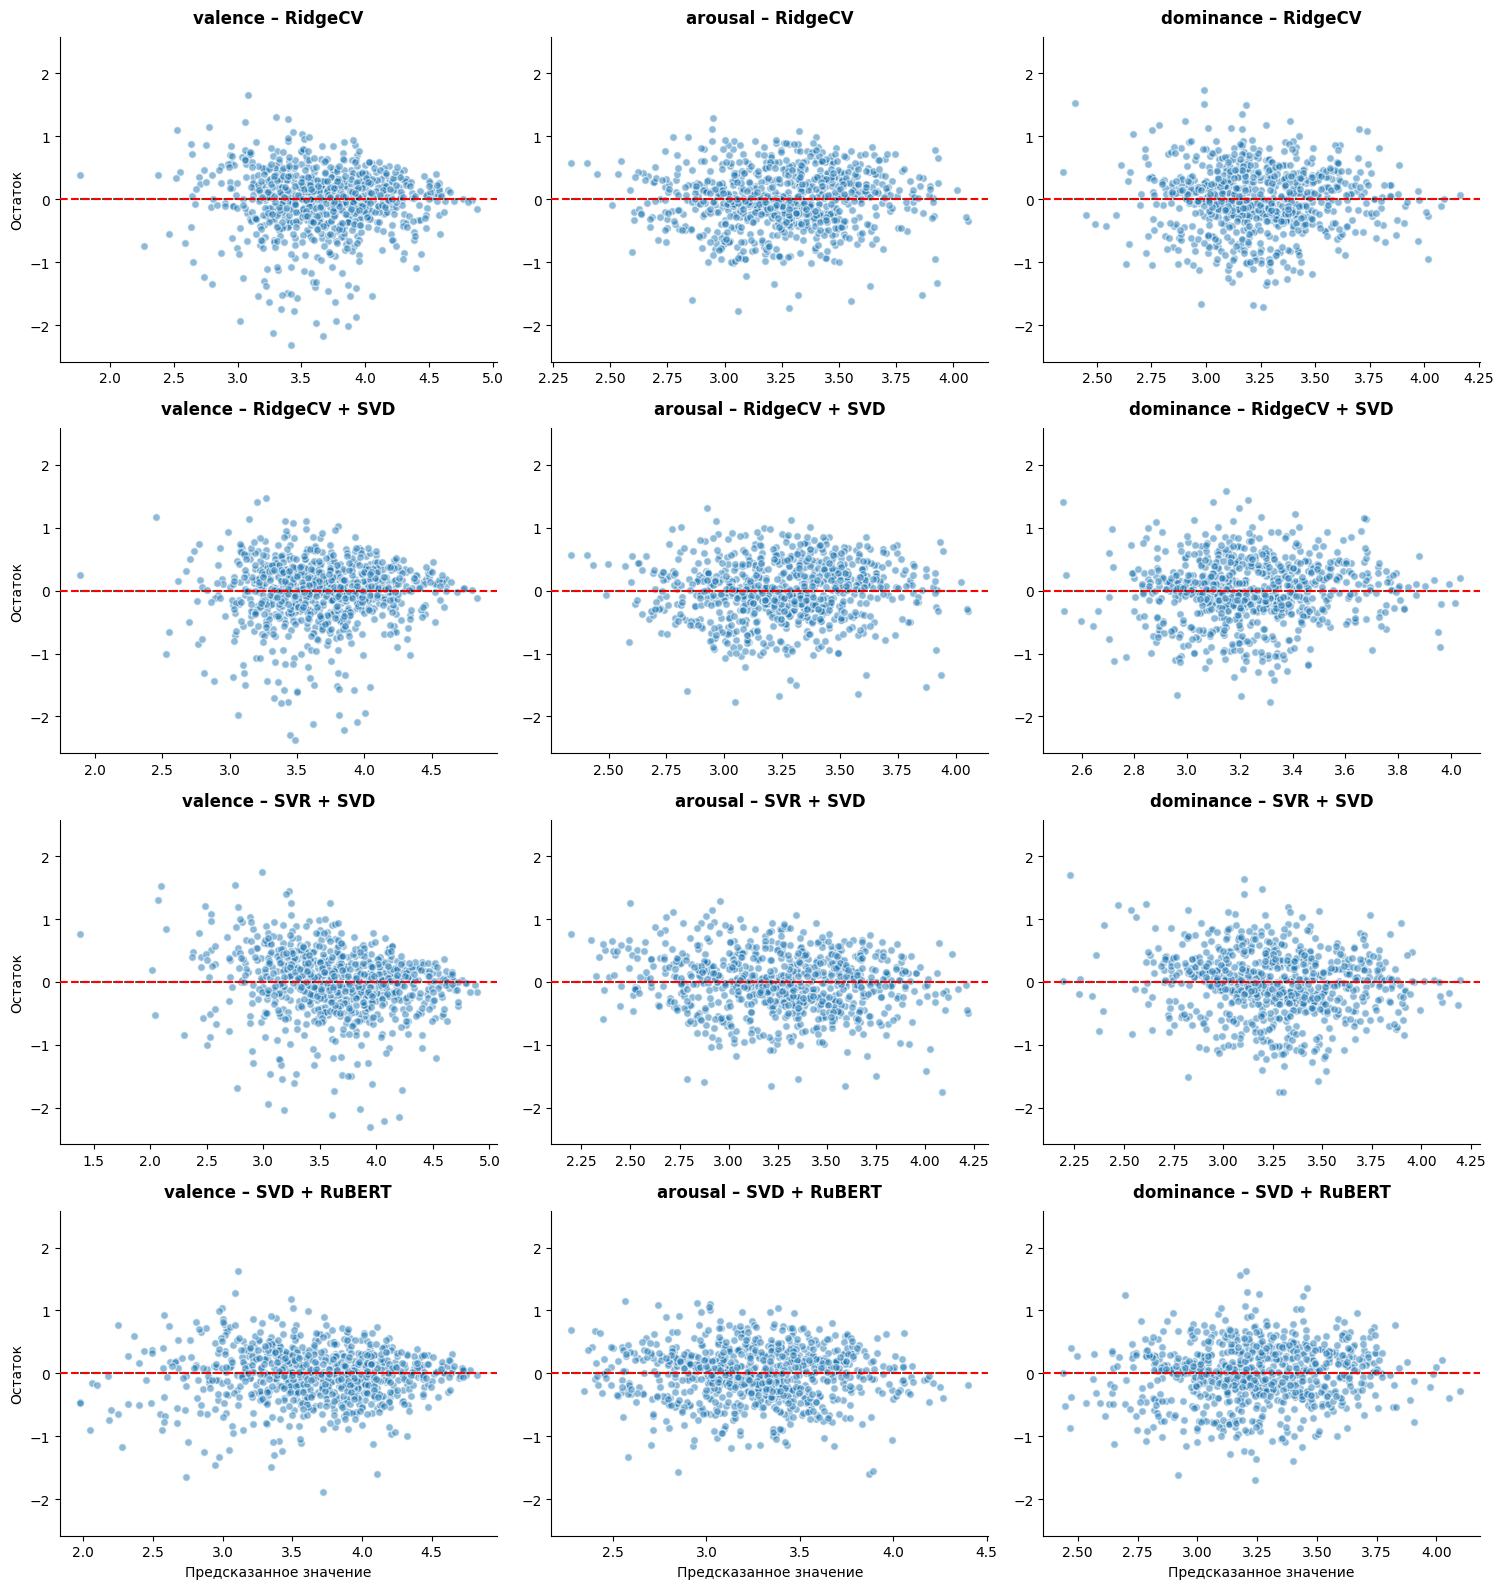

In [45]:
#график PredictionErrorDisplay
models = [
    ('RidgeCV', oof_ridge),
    ('RidgeCV + SVD', oof_lsa),
    ('SVR + SVD', oof_svr),
    ('SVD + RuBERT', oof_hybrid)
]

scales = ['valence', 'arousal', 'dominance']


fig, axes = plt.subplots(len(models), len(scales), figsize=(15, 16), facecolor='white')

global_res_min = min((y[s].astype(float) - oof_preds[s].astype(float)).min() for _, oof_preds in models for s in scales)
global_res_max = max((y[s].astype(float) - oof_preds[s].astype(float)).max() for _, oof_preds in models for s in scales)
abs_max = max(abs(global_res_min), abs(global_res_max))

for row_idx, (model_name, oof_preds) in enumerate(models):
    for col_idx, scale in enumerate(scales):
        ax = axes[row_idx, col_idx]

        y_true = y[scale].astype(float)
        y_pred = oof_preds[scale].astype(float)


        PredictionErrorDisplay.from_predictions(
            y_true=y_true,
            y_pred=y_pred,
            kind="residual_vs_predicted",
            ax=ax,
            scatter_kwargs={"alpha": 0.5, "edgecolors": 'w', "s": 30}
        )


        ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, zorder=3)

        ax.set_ylim(-abs_max - 0.2, abs_max + 0.2)

        ax.set_title(f'{scale} – {model_name}', fontsize=12, fontweight='bold', pad=10)

        if row_idx == len(models) - 1:
            ax.set_xlabel('Предсказанное значение', fontsize=10)
        else:
            ax.set_xlabel('')

        if col_idx == 0:
            ax.set_ylabel('Остаток', fontsize=10)
        else:
            ax.set_ylabel('')


        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

На графиках представлен визуальный анализ остатков для четырех исследуемых моделей в разрезе шкал valence, arousal и dominance.
Ключевое различие между моделями заключается в дисперсии и наличии экстремальных выбросов.
При переходе от базовых моделей к гибридной архитектуре **SVD + RuBERT** (нижний ряд) наблюдаются следующие качественные улучшения.

1.	Снижение дисперсии ошибки. График демонстрирует, что облако распределения точек визуально становится более плотным и компактным. Это коррелирует со снижением метрик MAE и RMSE.   2.	 Уменьшение ошибок с большой разницей. На графиках RidgeCV наблюдаются тяжелые «хвосты»  – значительное количество точек с ошибкой прогноза > 1.5. В модели **SVD + RuBERT** количество таких грубых промахов сокращается, особенно это видно на концах шкал.






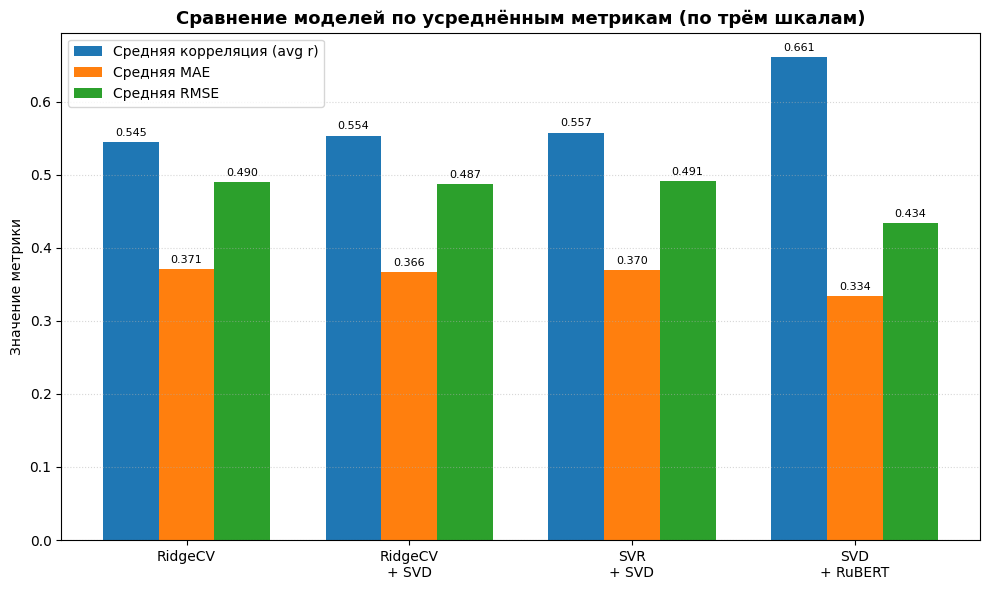

In [46]:

models_names = [
    'RidgeCV',
    'RidgeCV\n+ SVD',
    'SVR\n+ SVD',
    'SVD\n+ RuBERT'
]

avg_r = [
    res_full['avg_r'],
    res_lsa['avg_r'],
    res_svr['avg_r'],
    res_hybrid['avg_r']
]

avg_mae = [
    np.mean([res_full['valence_MAE'], res_full['arousal_MAE'], res_full['dominance_MAE']]),
    np.mean([res_lsa['valence_MAE'], res_lsa['arousal_MAE'], res_lsa['dominance_MAE']]),
    np.mean([res_svr['valence_MAE'], res_svr['arousal_MAE'], res_svr['dominance_MAE']]),
    np.mean([res_hybrid['valence_MAE'], res_hybrid['arousal_MAE'], res_hybrid['dominance_MAE']])
]

avg_rmse = [
    np.mean([res_full['valence_RMSE'], res_full['arousal_RMSE'], res_full['dominance_RMSE']]),
    np.mean([res_lsa['valence_RMSE'], res_lsa['arousal_RMSE'], res_lsa['dominance_RMSE']]),
    np.mean([res_svr['valence_RMSE'], res_svr['arousal_RMSE'], res_svr['dominance_RMSE']]),
    np.mean([res_hybrid['valence_RMSE'], res_hybrid['arousal_RMSE'], res_hybrid['dominance_RMSE']])
]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, avg_r, width, label='Средняя корреляция (avg r)', color='#1f77b4')
bars2 = ax.bar(x, avg_mae, width, label='Средняя MAE', color='#ff7f0e')
bars3 = ax.bar(x + width, avg_rmse, width, label='Средняя RMSE', color='#2ca02c')


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=10)
ax.set_title('Сравнение моделей по усреднённым метрикам (по трём шкалам)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylabel('Значение метрики')
plt.tight_layout()
plt.show()

На столбчатой диаграмме представлена итоговая оценка качества четырех моделей. Метрики (корреляция Пирсона, MAE и RMSE) усреднены по всем трем исследуемым шкалам для комплексного сравнения.

График наглядно иллюстрирует два важных момента.

Во-первых, первые три модели показывают практически идентичную предсказательную силу. Средняя корреляция останавливается на отметке примерно 0.55,  показатели ошибок почти одинаковые.

Во-вторых, переход к модели SVD + RuBERT обеспечил достаточный скачок метрик. Средняя корреляция (avg r) возрастает до 0.661, про этом наблюдается падание метрик ошибки (MAE снижается до 0.334, RMSE — до 0.434).

Итак, обогащение структурной информации из ассоциативного графа (SVD) контекстуализированными признаками из нейросетевой языковой модели (RuBERT) увеличивает эффективность экстраполяции аффективных норм.


### 4.1. Анализ ошибок лучшей модели

In [47]:
def export_all_models_to_excel(model_dict, y_true, filename="vad_all_models1.xlsx"):
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for model_name, oof_preds in model_dict.items():
            report = pd.DataFrame(index=y_true.index)

            for scale in ['valence', 'arousal', 'dominance']:
                report[f'true_{scale}'] = y_true[scale].astype(float)
                report[f'pred_{scale}'] = oof_preds[scale].astype(float)

                report[f'diff_{scale}'] = report[f'pred_{scale}'] - report[f'true_{scale}']

            report['lemma'] = report.index
            report = report.reset_index(drop=True)
            report['lemma'] = report['lemma'].astype(str).str.strip().str.lower()

            cols_order = ['lemma']
            for scale in ['valence', 'arousal', 'dominance']:
                cols_order += [f'true_{scale}', f'pred_{scale}', f'diff_{scale}']

            report = report[cols_order]
            report.iloc[:, 1:] = report.iloc[:, 1:].round(4)

            report.to_excel(writer, sheet_name=model_name, index=False)

In [48]:

models_dict = {
    "RidgeCV": oof_ridge,
    "RidgeCV + SVD": oof_lsa,
    "SVR + SVD": oof_svr,
    "SVD + RuBERT": oof_hybrid
}

export_all_models_to_excel(models_dict, y)

df_best_model = pd.read_excel("vad_all_models1.xlsx", sheet_name=3)


print("Статистика для лучшей модели (SVD + RuBERT):")
print(df_best_model.iloc[:, 1:].describe().T)

Статистика для лучшей модели (SVD + RuBERT):
                count      mean       std     min       25%      50%  \
true_valence    856.0  3.628004  0.658249  1.0930  3.289625  3.69115   
pred_valence    856.0  3.655789  0.513733  1.9748  3.349175  3.67730   
diff_valence    856.0  0.027783  0.415205 -1.6275 -0.229325  0.00645   
true_arousal    856.0  3.242314  0.552497  1.2500  2.933300  3.19675   
pred_arousal    856.0  3.264427  0.373680  2.2771  3.020075  3.27215   
diff_arousal    856.0  0.022116  0.424796 -1.1441 -0.257150  0.00575   
true_dominance  856.0  3.223057  0.557496  1.3077  2.941200  3.17240   
pred_dominance  856.0  3.240902  0.280946  2.4382  3.054625  3.23000   
diff_dominance  856.0  0.017844  0.460380 -1.6235 -0.291550  0.00325   

                     75%     max  
true_valence    4.069850  4.9592  
pred_valence    4.022050  4.8244  
diff_valence    0.273900  1.8808  
true_arousal    3.683950  4.7000  
pred_arousal    3.510850  4.4026  
diff_arousal    0.285800

Анализ описательных статистик истинных значений (true), предсказанных значений (pred) и их разностей (diff) позволяет сделать несколько важных выводов о характере работы лучшей модели на тестовой выборке (856 лемм).


1. **Средние значения (mean)** предсказаний модели практически полностью совпадают с истинными средними по всем трем шкалам. Например, для valence истинное среднее равно 3.628, а предсказанное - 3.655. Средняя ошибка (mean diff) по всем шкалам колеблется в пределах от 0.017 до 0.027. Медианная ошибка (50% квантиль для diff) для всех шкал также стремится к нулю (0.003 – 0.006). Это доказывает, что у модели нет систематического перекоса.

2. **Анализ 25-го и 75-го перцентилей для разностей** (diff) показывает высокую концентрацию предсказаний в одном интервале. Для половины всех анализируемых слов (между 25% и 75%) модель ошибается менее чем на 0.3.
Важно, что исследование межквартильного размаха истинных значений подтверждает гипотезу о высокой концентрации лексики в нейтральной зоне шкал (диапазон примерно 2.9-4.0). Это означает, что 50% объема обучающего датасета приходится на слова с умеренными аффективными характеристиками. Безусловно, это повлияло на эффективность модели. Поскольку модель видит подавляющее большинство примеров в нейтральном диапазоне, она «научилась» предсказывать именно этот интервал с высокой точностью (ошибка < 0.3). Ошибки модели, которые наблюдаются на краях шкал (1.0–2.0 или 4.5–5.0), могут являться прямым следствием дисбаланса данных. Модель не может точно предсказать экстремальные значения, потому что они составляют статистическое меньшинство.

3. **Сравнение стандартных отклонений (std) и экстремумов (min, max)** демонстрирует слабое место модели – регрессия к среднему.  
Итак, стандартное отклонение предсказаний стабильно ниже истинного. Особенно ярко это проявляется на шкале dominance, для которой дисперсия сжимается в два раза (истинное std 0.557 – предсказанное 0.280).
Эти данные еще раз подтверждают, что модель избегает категоричных оценок. Если истинное valence в датасете опускается до 1.09 (ярко выраженный негатив), то минимальный прогноз модели останавливается на 1.97. На шкале dominance истинный минимум равен 1.30, однако модель не выдала ни одного значения ниже 2.43.


Для комплексной оценки качества лучшей модели были построены два типа графиков: диаграммы рассеяния (соотношение истинных и предсказанных значений) и гистограммы распределения абсолютных ошибок по трем шкалам.

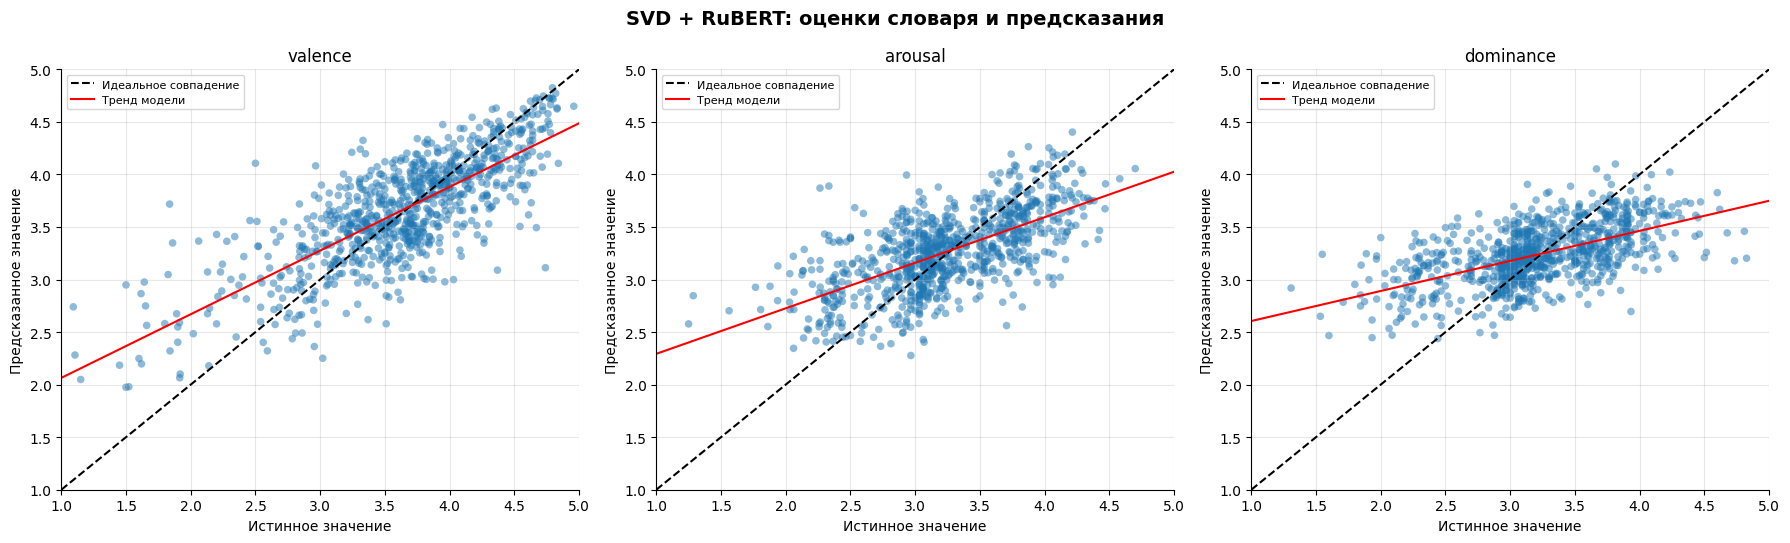

In [49]:
scales = ['valence', 'arousal', 'dominance']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')
fig.suptitle('SVD + RuBERT: оценки словаря и предсказания', fontsize=14, fontweight='bold')

for col_idx, scale in enumerate(scales):
    ax = axes[col_idx]
    y_true = y[scale].values
    y_pred = oof_hybrid[scale].values

    ax.scatter(y_true, y_pred, alpha=0.5, edgecolors='none', s=30, color='#1f77b4')
    ax.plot([1, 5], [1, 5], 'k--', linewidth=1.5, label='Идеальное совпадение')


    lr = LinearRegression().fit(y_true.reshape(-1, 1), y_pred)
    x_line = np.linspace(1, 5, 100)
    ax.plot(x_line, lr.predict(x_line.reshape(-1, 1)), 'r-', linewidth=1.5, label='Тренд модели')

    ax.set_xlabel('Истинное значение')
    ax.set_ylabel('Предсказанное значение')
    ax.set_title(scale)
    ax.legend(fontsize=8)
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.grid(alpha=0.3)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


На диаграммах рассеяния черная пунктирная линия отображает идеальный прогноз, а красная сплошная линия показывает реальный линейный тренд предсказаний модели.
Наглядно наблюдается **регрессия к среднему**, так как на всех трех шкалах красная линия тренда пересекает черную пунктирную. Так, модель завышает оценки для ярко выраженных негативных/низких стимулов и занижает оценки для сверхпозитивных/высоких стимулов.
Лучшее совпадение трендов наблюдается на шкале **valence**. Здесь облако точек наиболее вытянуто вдоль идеальной прямой. Наибольшие трудности алгоритм испытывает со шкалой **dominance**. В этом случае красная линия тренда имеет наименьший угол наклона, что говорит о сильном «стягивании» всех прогнозов к нейтральной середине


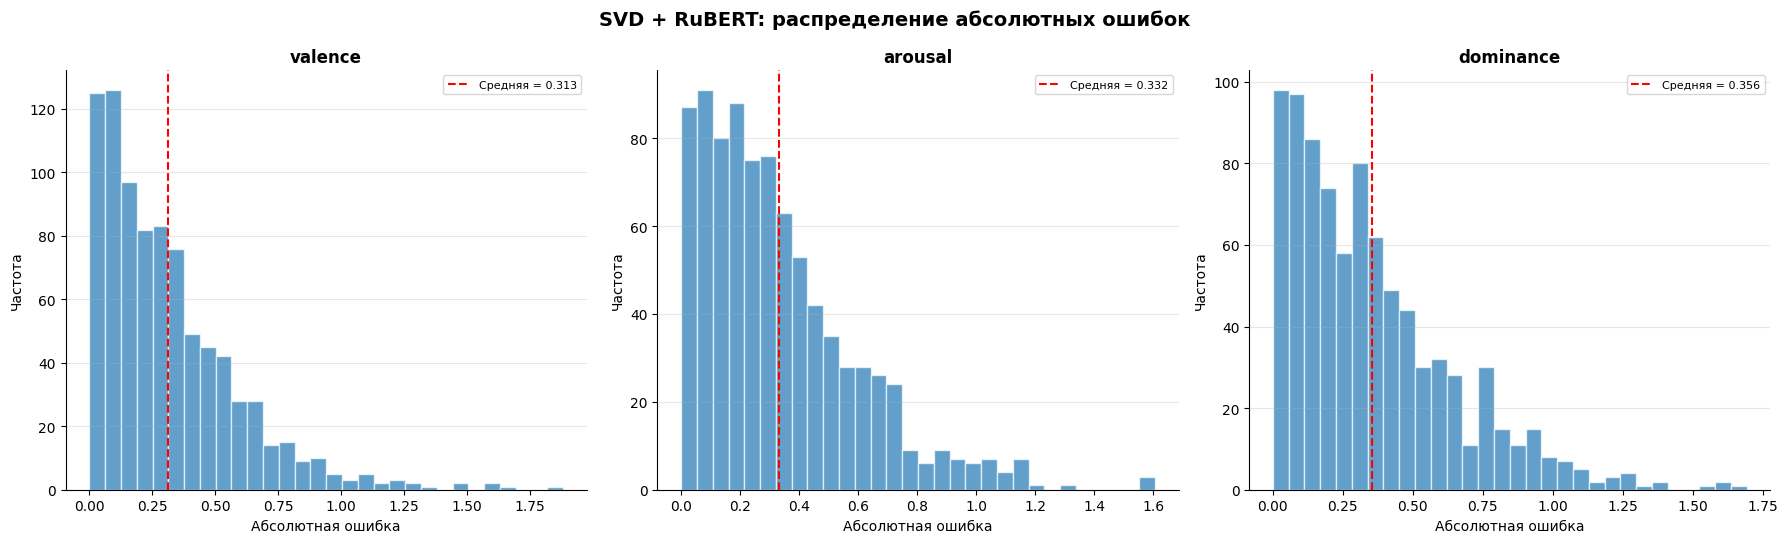

In [50]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')
fig.suptitle('SVD + RuBERT: распределение абсолютных ошибок', fontsize=14, fontweight='bold')

for col_idx, scale in enumerate(scales):
    ax = axes[col_idx]
    abs_errors = np.abs(oof_hybrid[scale].values - y[scale].values)

    ax.hist(abs_errors, bins=30, color='#1f77b4', alpha=0.7, edgecolor='white')
    mean_err = np.mean(abs_errors)
    ax.axvline(mean_err, color='red', linestyle='--', linewidth=1.5,
               label=f'Средняя = {mean_err:.3f}')

    ax.set_xlabel('Абсолютная ошибка')
    ax.set_ylabel('Частота')


    ax.set_title(scale, fontsize=12, fontweight='semibold')

    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Гистограммы демонстрируют частоту встречаемости ошибок определенного размера. Красная пунктирная линия отмечает среднюю абсолютную ошибку (MAE).
Графики имеют ярко выраженное правостороннее (положительное) скошенное распределение. Подавляющее большинство ошибок сгруппировано в левой части графиков (от 0.0 до 0.25). Это означает, что для ядра ассоциативного словаря модель выдает практически идеальные предсказания.
Средние значения ошибок (MAE) колеблются в узком интервале от 0.313 (valence) до 0.356 (dominance). Ошибки размером более 1.0 балла являются редкими единичными выбросами.


In [51]:
scales = ['valence', 'arousal', 'dominance']

for scale in scales:
    diff_col = f'diff_{scale}'
    true_col = f'true_{scale}'
    pred_col = f'pred_{scale}'

    cols_to_show = ['lemma', true_col, pred_col, diff_col]

    print(f"Анализ ошибок для шкалы {scale.upper()}")
    print("="*50)

    top_positive = df_best_model.sort_values(by=diff_col, ascending=False).head(10)[cols_to_show]
    top_negative = df_best_model.sort_values(by=diff_col, ascending=True).head(10)[cols_to_show]

    print(f"\nТОП-10 переоцененных слов, то есть модель завысила балл (Pred > True):")
    print(top_positive.to_string(index=False, formatters={true_col: '{:.2f}'.format, pred_col: '{:.2f}'.format, diff_col: '{:+.2f}'.format}))

    print(f"\nТОП-10 неодоцененных слов, то есть модель занизила балл (Pred < True):")
    print(top_negative.to_string(index=False, formatters={true_col: '{:.2f}'.format, pred_col: '{:.2f}'.format, diff_col: '{:+.2f}'.format}))

Анализ ошибок для шкалы VALENCE

ТОП-10 переоцененных слов, то есть модель завысила балл (Pred > True):
   lemma true_valence pred_valence diff_valence
 очередь         1.84         3.72        +1.88
   война         1.09         2.74        +1.65
господин         2.50         4.11        +1.61
  глупый         1.86         3.35        +1.49
потерять         1.50         2.95        +1.45
  плохой         1.64         2.98        +1.33
 плакать         2.06         3.37        +1.30
проблема         1.62         2.87        +1.25
зависеть         2.20         3.43        +1.23
 бояться         1.83         3.05        +1.22

ТОП-10 неодоцененных слов, то есть модель занизила балл (Pred < True):
     lemma true_valence pred_valence diff_valence
  смеяться         4.74         3.11        -1.63
    лесной         4.37         3.09        -1.28
     герой         4.67         3.49        -1.18
       лес         4.54         3.51        -1.04
автомобиль         4.03         3.00        -1

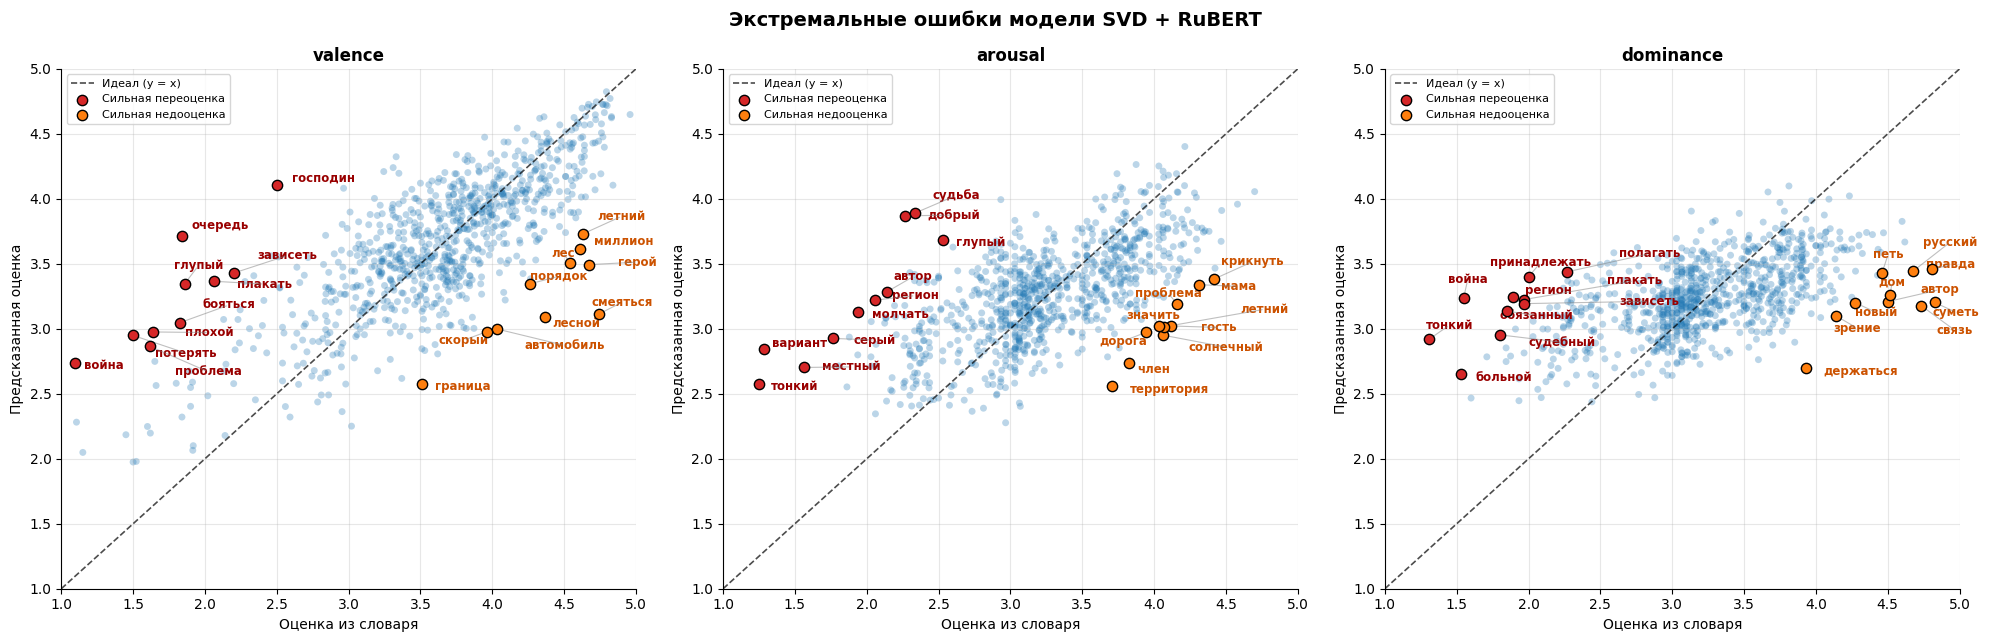

In [52]:

scales = ['valence', 'arousal', 'dominance']
N_TOP = 10

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), facecolor='white')
fig.suptitle('Экстремальные ошибки модели SVD + RuBERT', fontsize=14, fontweight='bold')

for col_idx, scale in enumerate(scales):
    ax = axes[col_idx]
    true_col = f'true_{scale}'
    pred_col = f'pred_{scale}'
    diff_col = f'diff_{scale}'

    ax.scatter(df_best_model[true_col], df_best_model[pred_col], alpha=0.3, edgecolors='none', s=25, color='#1f77b4')
    ax.plot([1, 5], [1, 5], 'k--', linewidth=1.2, alpha=0.7, label='Идеал (y = x)')

    top_overestimated = df_best_model.nlargest(N_TOP, diff_col)
    top_underestimated = df_best_model.nsmallest(N_TOP, diff_col)

    ax.scatter(top_overestimated[true_col], top_overestimated[pred_col],
               color='#d62728', s=55, edgecolors='black', label='Сильная переоценка', zorder=5)
    ax.scatter(top_underestimated[true_col], top_underestimated[pred_col],
               color='#ff7f0e', s=55, edgecolors='black', label='Сильная недооценка', zorder=5)


    texts = []


    for _, row in top_overestimated.iterrows():
        texts.append(ax.text(row[true_col], row[pred_col], row['lemma'],
                             fontsize=8.5, fontweight='bold', color='#990000'))


    for _, row in top_underestimated.iterrows():
        texts.append(ax.text(row[true_col], row[pred_col], row['lemma'],
                             fontsize=8.5, fontweight='bold', color='#cc5200'))


    adjust_text(texts, ax=ax, expand_points=(1.6, 1.6),
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, linewidth=0.8))


    ax.set_xlabel('Оценка из словаря')
    ax.set_ylabel('Предсказанная оценка')
    ax.set_title(scale, fontsize=12, fontweight='semibold')
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.grid(alpha=0.3)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)


    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Визуализация выбросов на графике и анализ топ-10 ошибок по каждой шкале позволяют перейти от статистики к пониманию лингвистической и когнитивной природы ошибок гибридной архитектуры SVD + RuBERT.
Ошибки модели не случайны, они носят ярко выраженный системный характер и сводятся к двум главным проблемам.
1. **Сглаживание аффекта.**
Слова с негативной коннотацией, вызывающие ощущение слабости (*война, плохой, плакать, больной*) при восприятии, получают завышенные оценки по шкалам valence и dominance.
Для ярко позитивных слов (*смеяться, герой, миллион, летний*) модель занижает оценки ближе к нейтральным.

2. **Диссонанс между дистрибутивной семантикой и психолингвистикой.**
Языковая модель (RuBERT) извлекает значения из контекстов употребления слов в текстах, тогда как люди оценивают слова через призму личного психологического опыта, в этом случае высоко влияние экстралингвистических факторов. Рассмотрим несколько примеров.
**Шкала valence.** Модель недооценивает позитивное влияние лексики, которая связана с природой и свободой пространства *(лес, лесной, летний*), воспринимает их скорее как нейтральные описательные прилагательные и существительные.
**Шкала dominance.** Для человека слова *зависеть, обязанный, больной, плакать* –  это маркеры абсолютной потери контроля над ситуацией (dominance < 2.0). А слова *суметь, правда, автор* – маркеры силы и субъектности (dominance > 4.5). Модель же плохо считывает этот скрытый уровень психологических особенностей восприятия и выдает для подобной лексики усредненные оценке в интервале 3.2 -3.4. Слово *война* для человека означает тотальную потерю контроля (dominance = 1.55), тогда как модель, вероятно, считывает его контекстуальную семантику и завышает jwtyreл до 3.24.
**Шкала arousal.** Модель приписывает высокую эмоциональную нагрузку словам, которые для человека являются семантически «тихими» или пассивными (*молчать, серый, тонкий*). И наоборот, экспрессивные действия (*крикнуть*) или значимые концепты (*территория, мама*) теряют для алгоритма силу интенсивности эмоциональной реакции.
